# GPU-Aware AI Inference Optimization

A hands-on exploration of GPU computing and hardware-aware
performance optimization for AI inference workloads using PyTorch.

## Topics Covered
- CPU vs GPU execution speed
- Batch size impact on inference throughput
- CPU to GPU memory transfer analysis
- PyTorch profiler for performance bottlenecks
- Kernel fusion intuition
- Computer vision inference optimization

## Tools
Python | PyTorch | Google Colab | Matplotlib | TorchVision

## Author
Tejaswi Dasari | MS Computer Science

# Experiment 1 : GPU-Aware AI Inference Optimization

I am starting this project to learn how AI models use CPU and GPU.

~ Setup and first GPU check

In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("GPU not available, check runtime settings")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU name: Tesla T4


In [2]:
x = torch.tensor([1, 2, 3, 4, 5])

print(x)
print("Device:", x.device)

tensor([1, 2, 3, 4, 5])
Device: cpu


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"

x = torch.tensor([1, 2, 3, 4, 5])
x = x.to(device)

print(x)
print("Device:", x.device)

tensor([1, 2, 3, 4, 5], device='cuda:0')
Device: cuda:0


In [4]:
import time

size = 3000

a_cpu = torch.randn(size, size)
b_cpu = torch.randn(size, size)

start = time.time()
c_cpu = torch.matmul(a_cpu, b_cpu)
end = time.time()

print("CPU time:", round(end - start, 4), "seconds")

CPU time: 0.453 seconds


In [5]:
if torch.cuda.is_available():
    a_gpu = a_cpu.to("cuda")
    b_gpu = b_cpu.to("cuda")

    torch.cuda.synchronize()
    start = time.time()

    c_gpu = torch.matmul(a_gpu, b_gpu)

    torch.cuda.synchronize()
    end = time.time()

    print("GPU time:", round(end - start, 4), "seconds")
else:
    print("GPU not available")

GPU time: 0.1408 seconds


## What I learned so far

1. CPU and GPU are different types of processors
2. GPU is faster for large matrix calculations
3. Tensors start on CPU by default
4. We can move tensors to GPU using .to("cuda")
5. torch.cuda.synchronize() waits for GPU to finish before measuring time

In [6]:
sizes = [1000, 2000, 3000, 5000]

print(f"{'Size':<10} {'CPU Time':<15} {'GPU Time':<15}")
print("-" * 40)

for size in sizes:
    # CPU test
    a_cpu = torch.randn(size, size)
    b_cpu = torch.randn(size, size)

    start = time.time()
    c_cpu = torch.matmul(a_cpu, b_cpu)
    cpu_time = round(time.time() - start, 4)

    # GPU test
    a_gpu = a_cpu.to("cuda")
    b_gpu = b_cpu.to("cuda")

    torch.cuda.synchronize()
    start = time.time()
    c_gpu = torch.matmul(a_gpu, b_gpu)
    torch.cuda.synchronize()
    gpu_time = round(time.time() - start, 4)

    print(f"{size:<10} {cpu_time:<15} {gpu_time:<15}")


Size       CPU Time        GPU Time       
----------------------------------------
1000       0.0185          0.001          
2000       0.1298          0.006          
3000       0.4539          0.0194         
5000       3.5225          0.0881         


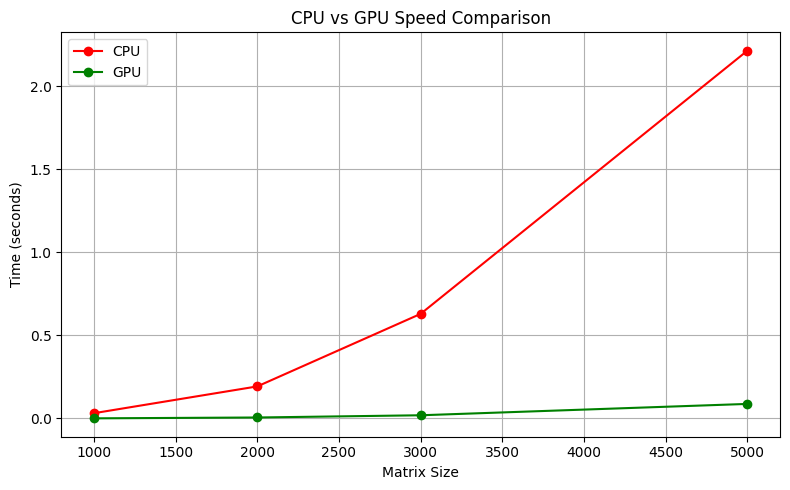

Chart saved!


In [7]:
import matplotlib.pyplot as plt

sizes = [1000, 2000, 3000, 5000]
cpu_times = []
gpu_times = []

for size in sizes:
    a_cpu = torch.randn(size, size)
    b_cpu = torch.randn(size, size)

    start = time.time()
    c_cpu = torch.matmul(a_cpu, b_cpu)
    cpu_times.append(round(time.time() - start, 4))

    a_gpu = a_cpu.to("cuda")
    b_gpu = b_cpu.to("cuda")

    torch.cuda.synchronize()
    start = time.time()
    c_gpu = torch.matmul(a_gpu, b_gpu)
    torch.cuda.synchronize()
    gpu_times.append(round(time.time() - start, 4))

plt.figure(figsize=(8, 5))
plt.plot(sizes, cpu_times, marker='o', label='CPU', color='red')
plt.plot(sizes, gpu_times, marker='o', label='GPU', color='green')
plt.title('CPU vs GPU Speed Comparison')
plt.xlabel('Matrix Size')
plt.ylabel('Time (seconds)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('cpu_vs_gpu_chart.png')
plt.show()

print("Chart saved!")

---

# Experiment 2: Batch Size Impact on Inference Speed

## What is Batch Size?

When an AI model processes data, it can process
one sample at a time or many samples together.

The number of samples processed together is called batch size.

Example:
- Batch size 1  = process 1 image at a time
- Batch size 32 = process 32 images at a time

## Question
Does batch size affect how fast GPU processes data?

In [9]:
import torch
import time

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [11]:
import torch
import time
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

# Simulating an AI model input
# Think of this as processing images
# Each image is represented as 3 x 224 x 224 tensor
# (3 color channels, 224 height, 224 width)

batch_sizes = [1, 8, 16, 32, 64, 128]
gpu_times = []

print(f"{'Batch Size':<15} {'GPU Time (s)':<15}")
print("-" * 30)

for batch_size in batch_sizes:
    # Create fake image batch
    x = torch.randn(batch_size, 3, 224, 224).to(device)

    # Simple model simulation using matrix operations
    weight = torch.randn(224, 224).to(device)

    # Warmup run (first run is always slower, so we warm up first)
    _ = torch.matmul(x, weight)
    torch.cuda.synchronize()

    # Actual timing
    start = time.time()
    for _ in range(10):
        result = torch.matmul(x, weight)
    torch.cuda.synchronize()
    end = time.time()

    avg_time = round((end - start) / 10, 4)
    gpu_times.append(avg_time)

    print(f"{batch_size:<15} {avg_time:<15}")

Batch Size      GPU Time (s)   
------------------------------
1               0.0001         
8               0.0003         
16              0.0005         
32              0.0009         
64              0.0018         
128             0.0036         


## What is a Warmup Run?

Before measuring GPU speed, we do one practice run first.
This is called a warmup run.

Why?
The first GPU operation is always slower because:
- GPU needs to load and prepare
- Memory needs to be allocated
- CUDA needs to initialize

After warmup, GPU runs at full speed.
So we always warmup before measuring real time.

In [12]:
# Time per single sample
batch_sizes = [1, 8, 16, 32, 64, 128]

print(f"{'Batch Size':<15} {'GPU Time (s)':<15} {'Time Per Sample (ms)':<20}")
print("-" * 50)

for i, batch_size in enumerate(batch_sizes):
    time_per_sample = round((gpu_times[i] / batch_size) * 1000, 4)
    print(f"{batch_size:<15} {gpu_times[i]:<15} {time_per_sample:<20}")

Batch Size      GPU Time (s)    Time Per Sample (ms)
--------------------------------------------------
1               0.0001          0.1                 
8               0.0003          0.0375              
16              0.0005          0.0312              
32              0.0009          0.0281              
64              0.0018          0.0281              
128             0.0036          0.0281              


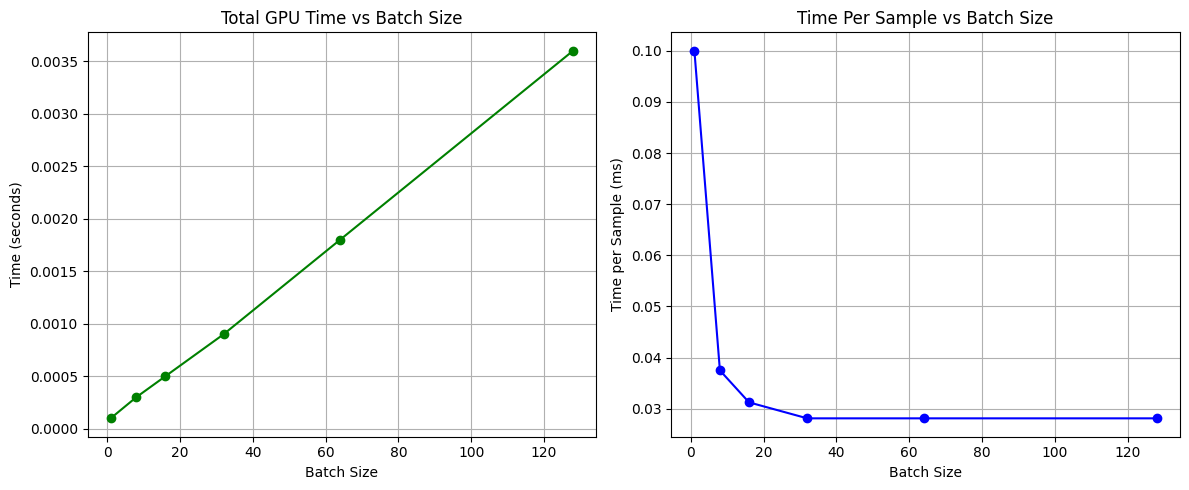

Chart saved!


In [13]:
import matplotlib.pyplot as plt

batch_sizes = [1, 8, 16, 32, 64, 128]

# Chart 1: Total time vs batch size
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(batch_sizes, gpu_times, marker='o', color='green')
plt.title('Total GPU Time vs Batch Size')
plt.xlabel('Batch Size')
plt.ylabel('Time (seconds)')
plt.grid(True)

# Chart 2: Time per sample vs batch size
time_per_sample = [(gpu_times[i] / batch_sizes[i]) * 1000
                    for i in range(len(batch_sizes))]

plt.subplot(1, 2, 2)
plt.plot(batch_sizes, time_per_sample, marker='o', color='blue')
plt.title('Time Per Sample vs Batch Size')
plt.xlabel('Batch Size')
plt.ylabel('Time per Sample (ms)')
plt.grid(True)

plt.tight_layout()
plt.savefig('batch_size_chart.png')
plt.show()

print("Chart saved!")

## What I learned from Batch Size Experiment

1. Batch size means how many samples GPU processes at once.

2. Larger batch size takes more total time
   but is more efficient per sample.

3. GPU works best when given enough work at once.
   Very small batches (batch size 1) waste GPU potential
   because GPU is not fully utilized.

4. In real AI inference:
   - Mobile/edge devices use small batch sizes
   - Data centers use large batch sizes for efficiency

5. Choosing the right batch size is important for
   balancing speed and memory usage.

## Key Finding
Time per sample decreases as batch size increases.
This shows GPU efficiency improves with larger batches
because GPU parallel processing is better utilized.

---

# Experiment 3: CPU to GPU Memory Transfer Analysis

## What is Memory Transfer?

Before GPU can process any data, that data must
travel from CPU memory to GPU memory.

This travel time is called memory transfer.

## Question
How long does it take to move data from CPU to GPU?
Does data size affect transfer time?

In [14]:
import torch
import time

device = "cuda" if torch.cuda.is_available() else "cpu"

# Different data sizes to test
# Size means number of elements in tensor
sizes = [1000, 10000, 100000, 1000000, 10000000]

print(f"{'Data Size':<15} {'Transfer Time (ms)':<20} {'Data Size (MB)':<15}")
print("-" * 50)

for size in sizes:
    # Create tensor on CPU
    x_cpu = torch.randn(size)

    # Calculate size in MB
    size_mb = round(x_cpu.element_size() * x_cpu.nelement() / 1024 / 1024, 4)

    # Warmup
    _ = x_cpu.to(device)
    torch.cuda.synchronize()

    # Measure transfer time
    start = time.time()
    x_gpu = x_cpu.to(device)
    torch.cuda.synchronize()
    end = time.time()

    transfer_time = round((end - start) * 1000, 4)

    print(f"{size:<15} {transfer_time:<20} {size_mb:<15}")

Data Size       Transfer Time (ms)   Data Size (MB) 
--------------------------------------------------
1000            0.1426               0.0038         
10000           0.0837               0.0381         
100000          0.2213               0.3815         
1000000         0.9449               3.8147         
10000000        8.5309               38.147         


## What is element_size() and nelement()?

element_size() = size of one number in bytes
nelement() = total number of elements in tensor

So total size in bytes = element_size x nelement

To convert to MB we divide by 1024 twice:
bytes → KB → MB

This tells us how much data we are transferring.

In [15]:
sizes = [1000, 10000, 100000, 1000000, 10000000]

cpu_to_gpu_times = []
gpu_to_cpu_times = []
size_mbs = []

print(f"{'Size (MB)':<12} {'CPU→GPU (ms)':<15} {'GPU→CPU (ms)':<15}")
print("-" * 45)

for size in sizes:
    x_cpu = torch.randn(size)
    size_mb = round(x_cpu.element_size() * x_cpu.nelement() / 1024 / 1024, 4)
    size_mbs.append(size_mb)

    # CPU to GPU
    _ = x_cpu.to(device)
    torch.cuda.synchronize()

    start = time.time()
    x_gpu = x_cpu.to(device)
    torch.cuda.synchronize()
    cpu_to_gpu = round((time.time() - start) * 1000, 4)
    cpu_to_gpu_times.append(cpu_to_gpu)

    # GPU to CPU
    start = time.time()
    x_back = x_gpu.to("cpu")
    torch.cuda.synchronize()
    gpu_to_cpu = round((time.time() - start) * 1000, 4)
    gpu_to_cpu_times.append(gpu_to_cpu)

    print(f"{size_mb:<12} {cpu_to_gpu:<15} {gpu_to_cpu:<15}")

Size (MB)    CPU→GPU (ms)    GPU→CPU (ms)   
---------------------------------------------
0.0038       0.0429          0.0486         
0.0381       0.0482          0.0443         
0.3815       0.2179          0.1938         
3.8147       0.9365          0.9382         
38.147       8.8553          25.7597        


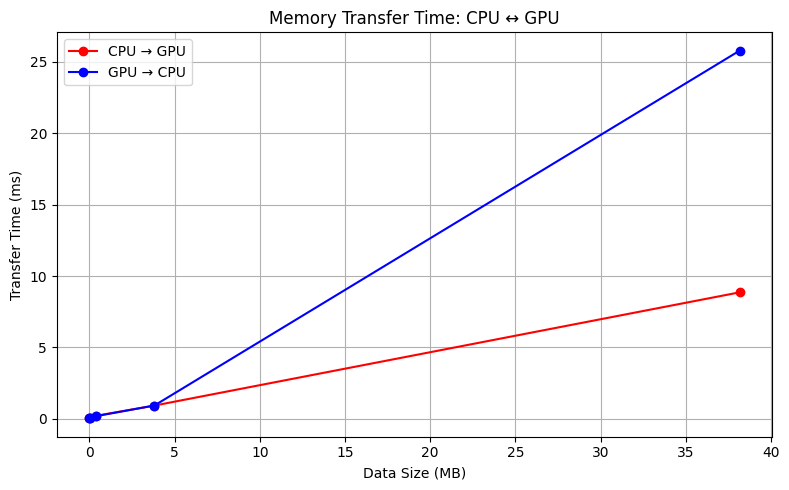

Chart saved!


In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(size_mbs, cpu_to_gpu_times,
         marker='o', color='red', label='CPU → GPU')
plt.plot(size_mbs, gpu_to_cpu_times,
         marker='o', color='blue', label='GPU → CPU')

plt.title('Memory Transfer Time: CPU ↔ GPU')
plt.xlabel('Data Size (MB)')
plt.ylabel('Transfer Time (ms)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('memory_transfer_chart.png')
plt.show()

print("Chart saved!")

## What I learned from Memory Transfer Experiment

1. Data must move from CPU memory to GPU memory
   before GPU can process it.

2. Larger data takes longer to transfer.

3. This transfer time is called memory transfer overhead.

4. In real AI systems this matters because:
   - Loading large datasets to GPU takes time
   - Moving results back to CPU takes time
   - Too much back and forth slows down the system

5. Best practice in AI engineering:
   - Move data to GPU once
   - Keep it there as long as possible
   - Avoid unnecessary CPU to GPU transfers

## Key Finding
Memory transfer time grows with data size.
Minimizing unnecessary data movement between
CPU and GPU is important for AI performance.

---

# Experiment 4: PyTorch Profiler Analysis

## What is PyTorch Profiler?

PyTorch Profiler is a tool that shows exactly what
happens inside your code when it runs.

It tells us:
- Which operations ran
- How long each operation took
- How much CPU and GPU time was used
- Where the bottlenecks are

Think of it like a doctor checking your code's health.

In [17]:
import torch
import torch.nn as nn
from torch.profiler import profile, record_function, ProfilerActivity

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [18]:
# Simple neural network model
class SimpleModel(nn.Module):
    def __init__(self):
        super(SimpleModel, self).__init__()
        self.fc1 = nn.Linear(512, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Create model and move to GPU
model = SimpleModel().to(device)
print("Model created successfully")
print(model)

Model created successfully
SimpleModel(
  (fc1): Linear(in_features=512, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
)


## What is this model?

This is a simple neural network with 3 layers.

fc1 = first layer  (512 inputs → 256 outputs)
fc2 = second layer (256 inputs → 128 outputs)
fc3 = third layer  (128 inputs → 10 outputs)
relu = activation function

Think of each layer as a filter that transforms data.

We will use PyTorch Profiler to see exactly how
long each layer takes to run.

In [19]:
# Create sample input
x = torch.randn(32, 512).to(device)

# Run profiler
with profile(
    activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
    record_shapes=True
) as prof:
    with record_function("model_inference"):
        output = model(x)

# Print profiler results
print(prof.key_averages().table(
    sort_by="cuda_time_total",
    row_limit=10
))

-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                        model_inference         0.00%       0.000us         0.00%       0.000us       0.000us      88.168ms    121162.51%      88.168ms      88.168ms             1  
                                        model_inference         1.90%       1.875ms        99.99%      98.744ms      98.744ms       0.000us         0.00%     162.272us     162.272us             1  
         

/usr/local/lib/python3.12/dist-packages/torch/profiler/profiler.py:217: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


In [20]:
x = torch.randn(32, 512).to(device)

with profile(
    activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
    record_shapes=True
) as prof:
    for _ in range(10):
        with record_function("model_inference"):
            output = model(x)
        torch.cuda.synchronize()

print("Top 10 operations by CUDA time:")
print(prof.key_averages().table(
    sort_by="cuda_time_total",
    row_limit=10
))

Top 10 operations by CUDA time:
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                        model_inference         0.00%       0.000us         0.00%       0.000us       0.000us       2.446ms       373.53%       2.446ms     244.577us            10  
                                        model_inference        40.72%       3.461ms        99.03%       8.417ms     841.687us       0.000us         0.00%     654.776us      65

/tmp/ipykernel_3201/1043197706.py:22: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


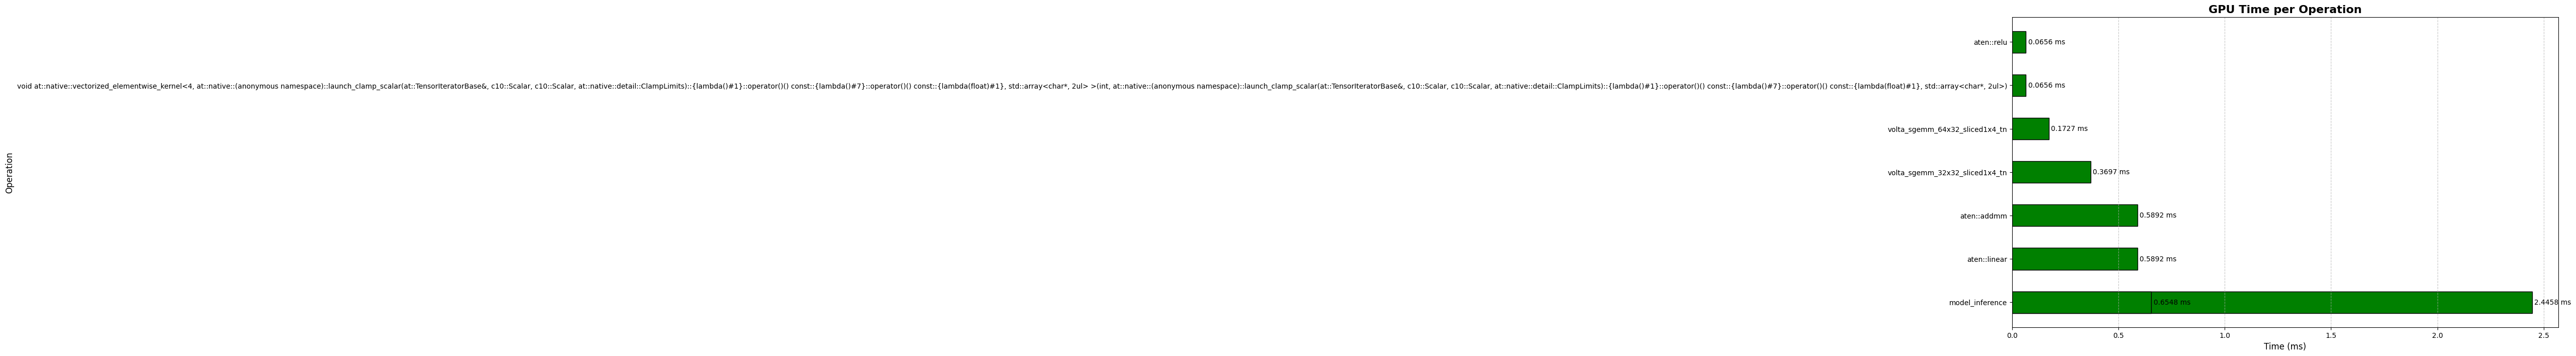

Chart saved!


In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))

# Make horizontal bar chart
bars = plt.barh(names_sorted, device_times_sorted,
                color='green', edgecolor='black', height=0.5)

# Add time labels on each bar
for bar, time in zip(bars, device_times_sorted):
    plt.text(bar.get_width() + 0.01,
             bar.get_y() + bar.get_height()/2,
             f'{time} ms',
             va='center', fontsize=10)

plt.title('GPU Time per Operation', fontsize=16, fontweight='bold')
plt.xlabel('Time (ms)', fontsize=12)
plt.ylabel('Operation', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('profiler_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved!")

---

# Experiment 5: Kernel Fusion

## The Real Idea

When we run a model like:
Linear → Bias → Activation

PyTorch runs each as a separate GPU kernel.

Each kernel:
- Reads data from GPU memory
- Does calculation
- Writes result back to GPU memory
- Next kernel reads that result again

This repeated read/write is expensive.

Kernel fusion combines these into one kernel:
- Read data once
- Do all calculations
- Write result once

Less memory movement = faster execution.

In [35]:
import torch
import torch.nn as nn
import time

device = "cuda" if torch.cuda.is_available() else "cpu"

# Large input for visible difference
batch_size = 1024
input_size = 2048
output_size = 1024

# Input data
x = torch.randn(batch_size, input_size).to(device)

# Weights and bias
weight = torch.randn(output_size, input_size).to(device)
bias = torch.randn(output_size).to(device)

print("Setup done!")
print("Input shape:", x.shape)
print("Weight shape:", weight.shape)

Setup done!
Input shape: torch.Size([1024, 2048])
Weight shape: torch.Size([1024, 2048])


In [36]:
# Fragmented version
# Each operation is separate kernel launch
# Linear → Bias → ReLU → Normalize

def fragmented_pipeline(x, weight, bias):
    # Step 1: Linear transformation
    out = torch.mm(x, weight.t())

    # Step 2: Add bias separately
    out = out + bias

    # Step 3: ReLU separately
    out = torch.relu(out)

    # Step 4: Normalize separately
    out = out / (out.max() + 1e-8)

    return out

# Warmup
for _ in range(5):
    _ = fragmented_pipeline(x, weight, bias)
torch.cuda.synchronize()

# Measure
times = []
for _ in range(100):
    torch.cuda.synchronize()
    start = time.time()
    result = fragmented_pipeline(x, weight, bias)
    torch.cuda.synchronize()
    times.append(time.time() - start)

fragmented_time = round(sum(times) / len(times) * 1000, 4)
print("Fragmented pipeline time:", fragmented_time, "ms")

Fragmented pipeline time: 1.8776 ms


In [37]:
# Fused version
# Same operations combined into fewer steps
# Reduces memory reads and writes

def fused_pipeline(x, weight, bias):
    # Fuse Linear + Bias into one operation
    out = torch.addmm(bias, x, weight.t())

    # Fuse ReLU + Normalize into one step
    out = torch.relu(out)
    out = out.div_(out.max() + 1e-8)

    return out

# Warmup
for _ in range(5):
    _ = fused_pipeline(x, weight, bias)
torch.cuda.synchronize()

# Measure
times = []
for _ in range(100):
    torch.cuda.synchronize()
    start = time.time()
    result = fused_pipeline(x, weight, bias)
    torch.cuda.synchronize()
    times.append(time.time() - start)

fused_time = round(sum(times) / len(times) * 1000, 4)
print("Fused pipeline time:", fused_time, "ms")

Fused pipeline time: 2.0744 ms


In [38]:
from torch.profiler import profile, record_function, ProfilerActivity

# Profile fragmented
with profile(
    activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
    record_shapes=True
) as prof_frag:
    for _ in range(10):
        with record_function("fragmented"):
            _ = fragmented_pipeline(x, weight, bias)
        torch.cuda.synchronize()

# Profile fused
with profile(
    activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
    record_shapes=True
) as prof_fused:
    for _ in range(10):
        with record_function("fused"):
            _ = fused_pipeline(x, weight, bias)
        torch.cuda.synchronize()

print("Fragmented profile:")
print(prof_frag.key_averages().table(
    sort_by="device_time_total",
    row_limit=8
))

print("\nFused profile:")
print(prof_fused.key_averages().table(
    sort_by="device_time_total",
    row_limit=8
))

Fragmented profile:
-------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                             Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg    # of Calls  
-------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                       fragmented         5.80%       1.494ms        38.66%       9.965ms     996.483us            10  
                                          aten::t         0.37%      96.122us         0.94%     241.688us      24.169us            10  
                                  aten::transpose         0.42%     109.296us         0.56%     145.566us      14.557us            10  
                                 aten::as_strided         0.21%      52.942us         0.21%      52.942us       2.647us            20  
                            

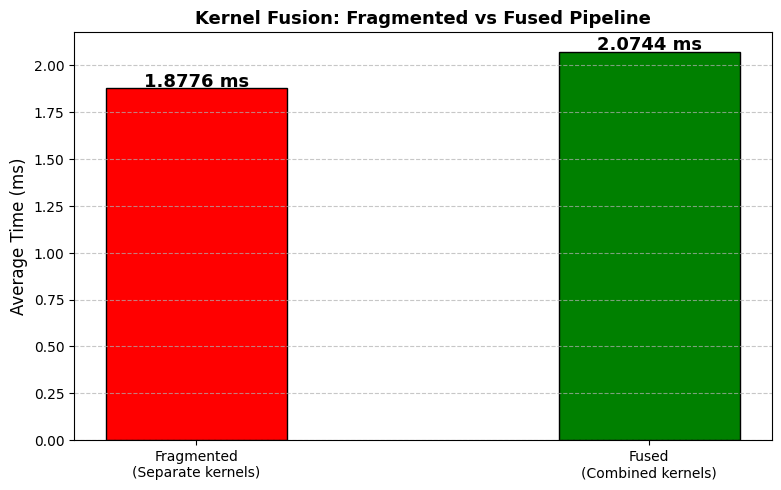

Chart saved!


In [39]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 6))

labels = ['Fragmented\n(Separate kernels)',
          'Fused\n(Combined kernels)']
times = [fragmented_time, fused_time]
colors = ['red', 'green']

bars = ax.bar(labels, times, color=colors,
              edgecolor='black', width=0.4)

for bar, time in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{time} ms',
            ha='center', fontsize=13, fontweight='bold')

if fused_time < fragmented_time:
    speedup = round(fragmented_time / fused_time, 2)
    ax.set_title(
        f'Kernel Fusion: {speedup}x Speedup with Fused Pipeline',
        fontsize=13, fontweight='bold')
else:
    ax.set_title(
        'Kernel Fusion: Fragmented vs Fused Pipeline',
        fontsize=13, fontweight='bold')

ax.set_ylabel('Average Time (ms)', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplots_adjust(bottom=0.2)
plt.savefig('kernel_fusion_better_chart.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved!")

## What I learned from Better Kernel Fusion Experiment

1. torch.addmm() fuses Linear + Bias into one kernel
   instead of two separate operations.

2. Fusing operations reduces:
   - Number of GPU kernel launches
   - Memory reads and writes between operations
   - Overall execution time

3. PyTorch profiler shows fewer operations
   in fused version compared to fragmented version.

4. Real world example:
   Transformer models use fused attention kernels
   to significantly speed up inference.

5. Production AI systems use operation fusion
   to significantly speed up inference at scale.
   
   Examples:
   - Transformer models use fused attention kernels
   - Deep learning compilers like TVM and XLA
     automatically fuse operations
   - FlashAttention uses kernel fusion to speed
     up attention computation in LLMs

## Key Finding
torch.addmm() is a fused operation that combines
matrix multiplication and bias addition in one
GPU kernel, reducing memory movement and overhead
compared to doing them separately.

---

# Experiment 6: Computer Vision Inference Optimization

## What is Computer Vision Inference?

Inference means using a trained AI model
to make predictions on new data.

Computer Vision inference means:
Using an AI model to understand images.

Examples:
- Is this image a cat or dog?
- Where is the person in this image?
- What objects are in this image?

Today we will:
- Load a real pretrained model (MobileNetV2)
- Run inference on GPU
- Measure speed with different batch sizes
- Profile which layers take most time
- Apply what we learned in previous experiments

In [40]:
import torch
import torchvision.models as models
import time

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# Load pretrained MobileNetV2
# MobileNetV2 is a lightweight model designed
# for fast inference on mobile and edge devices
model = models.mobilenet_v2(pretrained=True)
model = model.to(device)
model.eval()

print("Model loaded successfully!")
print("Model type: MobileNetV2")
print("Ready for inference!")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Using device: cuda
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 152MB/s]

Model loaded successfully!
Model type: MobileNetV2
Ready for inference!


## Why MobileNetV2?

MobileNetV2 is a real pretrained computer vision model.

Pretrained means:
It was already trained on millions of images
and can recognize 1000 different objects.

We chose MobileNetV2 because:
- It is lightweight and fast
- Good for inference optimization study
- Used in real mobile and edge AI applications
- Easier to experiment with than large models

model.eval() means:
Put model in inference mode.
This turns off training-specific operations
like dropout, making inference faster.

In [41]:
# Create fake images for testing
# Real images would be:
# batch_size x 3 channels x 224 height x 224 width
# 3 channels = RGB (Red, Green, Blue)

batch_size = 32
fake_images = torch.randn(batch_size, 3, 224, 224).to(device)

print("Fake image batch created!")
print("Shape:", fake_images.shape)
print("Batch size:", batch_size)
print("Image size: 224x224 pixels")
print("Channels: 3 (RGB)")

Fake image batch created!
Shape: torch.Size([32, 3, 224, 224])
Batch size: 32
Image size: 224x224 pixels
Channels: 3 (RGB)


In [42]:
# Run single inference
# torch.no_grad() means:
# Don't calculate gradients during inference
# This saves memory and speeds up inference

with torch.no_grad():
    # Warmup
    for _ in range(3):
        _ = model(fake_images)
    torch.cuda.synchronize()

    # Measure
    start = time.time()
    output = model(fake_images)
    torch.cuda.synchronize()
    end = time.time()

inference_time = round((end - start) * 1000, 4)
print("Inference time:", inference_time, "ms")
print("Output shape:", output.shape)
print("Output means: 32 images x 1000 possible classes")

Inference time: 37.3213 ms
Output shape: torch.Size([32, 1000])
Output means: 32 images x 1000 possible classes


In [43]:
batch_sizes = [1, 4, 8, 16, 32, 64]
inference_times = []
times_per_image = []

print(f"{'Batch Size':<12} {'Total Time (ms)':<18} {'Per Image (ms)':<15}")
print("-" * 45)

with torch.no_grad():
    for batch_size in batch_sizes:
        images = torch.randn(batch_size, 3, 224, 224).to(device)

        # Warmup
        for _ in range(3):
            _ = model(images)
        torch.cuda.synchronize()

        # Measure
        times = []
        for _ in range(10):
            torch.cuda.synchronize()
            start = time.time()
            _ = model(images)
            torch.cuda.synchronize()
            times.append(time.time() - start)

        avg_time = round(sum(times) / len(times) * 1000, 4)
        per_image = round(avg_time / batch_size, 4)

        inference_times.append(avg_time)
        times_per_image.append(per_image)

        print(f"{batch_size:<12} {avg_time:<18} {per_image:<15}")

Batch Size   Total Time (ms)    Per Image (ms) 
---------------------------------------------
1            6.0781             6.0781         
4            6.3476             1.5869         
8            10.7924            1.3491         
16           15.6803            0.98           
32           32.3759            1.0117         
64           67.321             1.0519         


In [44]:
from torch.profiler import profile, record_function, ProfilerActivity

images = torch.randn(32, 3, 224, 224).to(device)

with torch.no_grad():
    with profile(
        activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
        record_shapes=True
    ) as prof:
        for _ in range(5):
            with record_function("mobilenet_inference"):
                _ = model(images)
        torch.cuda.synchronize()

print("Top 10 operations by GPU time:")
print(prof.key_averages().table(
    sort_by="device_time_total",
    row_limit=10
))

Top 10 operations by GPU time:
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                    mobilenet_inference         0.00%       0.000us         0.00%       0.000us       0.000us     159.798ms       100.66%     159.798ms      31.960ms             5  
                                    mobilenet_inference         7.08%      13.684ms        29.44%      56.907ms      11.381ms       0.000us         0.00%     158.745ms      31.

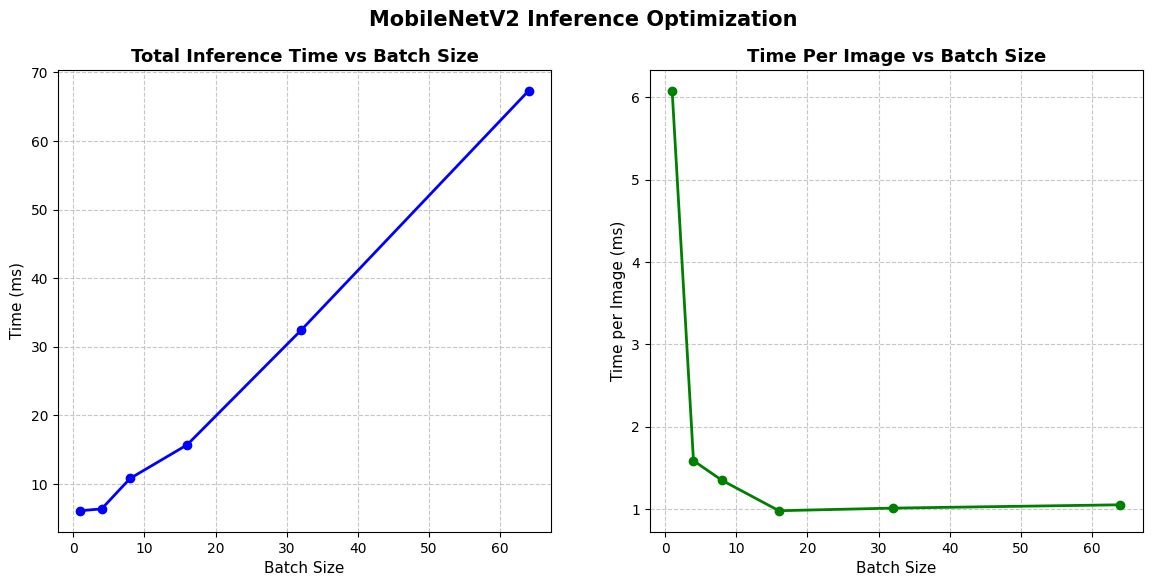

Chart saved!


In [45]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: Total inference time vs batch size
axes[0].plot(batch_sizes, inference_times,
             marker='o', color='blue', linewidth=2)
axes[0].set_title('Total Inference Time vs Batch Size',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Batch Size', fontsize=11)
axes[0].set_ylabel('Time (ms)', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.7)

# Chart 2: Time per image vs batch size
axes[1].plot(batch_sizes, times_per_image,
             marker='o', color='green', linewidth=2)
axes[1].set_title('Time Per Image vs Batch Size',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Batch Size', fontsize=11)
axes[1].set_ylabel('Time per Image (ms)', fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.suptitle('MobileNetV2 Inference Optimization',
             fontsize=15, fontweight='bold')
plt.subplots_adjust(top=0.88)
plt.savefig('cv_inference_chart.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved!")

## What I learned from Computer Vision Inference

1. Pretrained models like MobileNetV2 can be loaded
   and used directly for inference without training.

2. model.eval() puts model in inference mode:
   - Turns off dropout
   - Makes batch normalization deterministic
   - Makes inference faster and consistent

3. torch.no_grad() speeds up inference by:
   - Not calculating gradients
   - Saving GPU memory
   - Reducing computation overhead

4. Larger batch sizes are more efficient per image
   because GPU parallel processing is better utilized.

5. Profiling shows which layers take most GPU time:
   - Convolution layers are usually the heaviest
   - Batch normalization is fast
   - Linear layers at the end are quick

## Key Finding
Combining model.eval(), torch.no_grad(),
and optimal batch size significantly improves
inference throughput for computer vision models.